# Data
---

In [43]:
# Dades ficticies
sample_data = [
  {"year": 2023, "month": "Jan", "angle_deg": 0, "radius_layer": 1, "volume_tb": 120.5},
  {"year": 2023, "month": "Feb", "angle_deg": 30, "radius_layer": 1, "volume_tb": 118.2},
  {"year": 2023, "month": "Mar", "angle_deg": 60, "radius_layer": 1, "volume_tb": 125.8},
  {"year": 2023, "month": "Apr", "angle_deg": 90, "radius_layer": 1, "volume_tb": 122.4},
  {"year": 2023, "month": "May", "angle_deg": 120, "radius_layer": 1, "volume_tb": 128.9},
  {"year": 2023, "month": "Jun", "angle_deg": 150, "radius_layer": 1, "volume_tb": 135.2},
  {"year": 2023, "month": "Jul", "angle_deg": 180, "radius_layer": 1, "volume_tb": 142.1},
  {"year": 2023, "month": "Aug", "angle_deg": 210, "radius_layer": 1, "volume_tb": 140.5},
  {"year": 2023, "month": "Sep", "angle_deg": 240, "radius_layer": 1, "volume_tb": 138.7},
  {"year": 2023, "month": "Oct", "angle_deg": 270, "radius_layer": 1, "volume_tb": 145.3},
  {"year": 2023, "month": "Nov", "angle_deg": 300, "radius_layer": 1, "volume_tb": 158.6},
  {"year": 2023, "month": "Dec", "angle_deg": 330, "radius_layer": 1, "volume_tb": 175.4},

  {"year": 2024, "month": "Jan", "angle_deg": 0, "radius_layer": 2, "volume_tb": 160.2},
  {"year": 2024, "month": "Feb", "angle_deg": 30, "radius_layer": 2, "volume_tb": 155.8},
  {"year": 2024, "month": "Mar", "angle_deg": 60, "radius_layer": 2, "volume_tb": 168.4},
  {"year": 2024, "month": "Apr", "angle_deg": 90, "radius_layer": 2, "volume_tb": 162.1},
  {"year": 2024, "month": "May", "angle_deg": 120, "radius_layer": 2, "volume_tb": 170.5},
  {"year": 2024, "month": "Jun", "angle_deg": 150, "radius_layer": 2, "volume_tb": 182.9},
  {"year": 2024, "month": "Jul", "angle_deg": 180, "radius_layer": 2, "volume_tb": 195.4},
  {"year": 2024, "month": "Aug", "angle_deg": 210, "radius_layer": 2, "volume_tb": 190.2},
  {"year": 2024, "month": "Sep", "angle_deg": 240, "radius_layer": 2, "volume_tb": 188.6},
  {"year": 2024, "month": "Oct", "angle_deg": 270, "radius_layer": 2, "volume_tb": 202.1},
  {"year": 2024, "month": "Nov", "angle_deg": 300, "radius_layer": 2, "volume_tb": 215.8},
  {"year": 2024, "month": "Dec", "angle_deg": 330, "radius_layer": 2, "volume_tb": 240.5},

  {"year": 2025, "month": "Jan", "angle_deg": 0, "radius_layer": 3, "volume_tb": 220.1},
  {"year": 2025, "month": "Feb", "angle_deg": 30, "radius_layer": 3, "volume_tb": 210.4},
  {"year": 2025, "month": "Mar", "angle_deg": 60, "radius_layer": 3, "volume_tb": 225.8},
  {"year": 2025, "month": "Apr", "angle_deg": 90, "radius_layer": 3, "volume_tb": 218.9},
  {"year": 2025, "month": "May", "angle_deg": 120, "radius_layer": 3, "volume_tb": 232.1},
  {"year": 2025, "month": "Jun", "angle_deg": 150, "radius_layer": 3, "volume_tb": 248.5},
  {"year": 2025, "month": "Jul", "angle_deg": 180, "radius_layer": 3, "volume_tb": 265.2},
  {"year": 2025, "month": "Aug", "angle_deg": 210, "radius_layer": 3, "volume_tb": 260.7},
  {"year": 2025, "month": "Sep", "angle_deg": 240, "radius_layer": 3, "volume_tb": 255.4},
  {"year": 2025, "month": "Oct", "angle_deg": 270, "radius_layer": 3, "volume_tb": 272.9},
  {"year": 2025, "month": "Nov", "angle_deg": 300, "radius_layer": 3, "volume_tb": 298.2},
  {"year": 2025, "month": "Dec", "angle_deg": 330, "radius_layer": 3, "volume_tb": 330.6}
]

# Documentació trobada amb Gemini
---

Basicament hem de donar uns valors (coordenades) polars/circulars a les nostres categories o dades que ja tenim/hem generat de manera artificial

>In Python, we create a spiral by converting your Time-Series data into Polar Coordinates ($r, \theta$). For your Network Volume data, we will follow this logic:Angle ($\theta$): The month (Jan=0°, Dec=330°).Radius ($r$): The year + a fraction of the month (to keep the line moving outward).Value: The color of the line/dots (Terabytes).


# Entorn
---


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Visualització
---

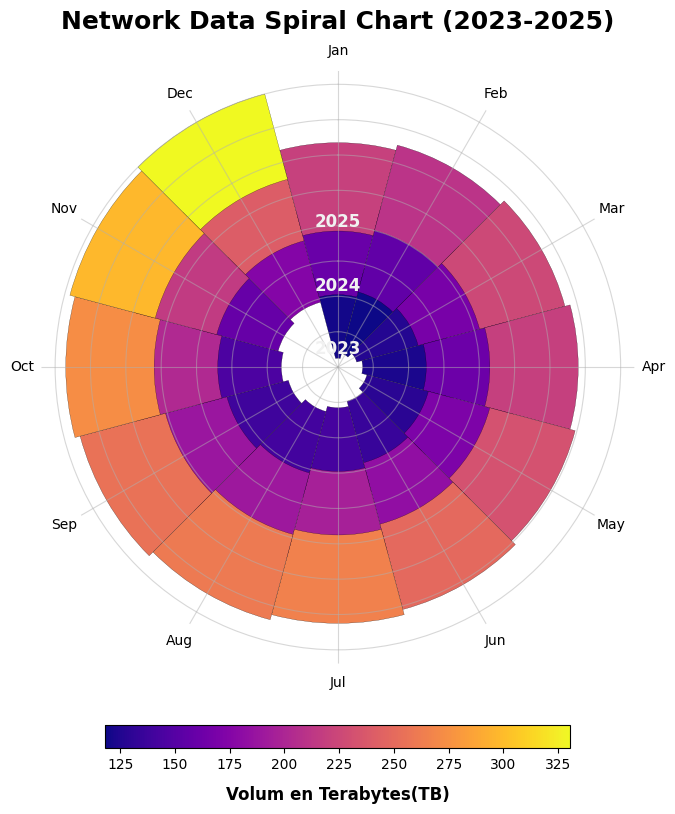

In [61]:
# Preparem dades i obtenim radians
df = pd.DataFrame(sample_data)
df['theta'] = np.radians(df['angle_deg'])

# Per generar la espiral
base_radius = 0.5
drift_speed = 0.3
df['radius'] = base_radius + (df.index * drift_speed)

# Plot
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'})
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

# Color
norm = plt.Normalize(df['volume_tb'].min(), df['volume_tb'].max())
cmap = cm.plasma

# Visualització en Espiral
width = np.radians(30)

for i, row in df.iterrows():
  ax.bar(
    x=row['theta'],
    height=5,
    width=width,
    bottom=row['radius'],
    color=cmap(norm(row['volume_tb'])),
    edgecolor='black',
    linewidth=0.15
  )

  # Label Anys
  if row['month'] == 'Jan':
    ax.text(row['theta'], row['radius'] + 0.5, str(int(row['year'])), ha='center', va='center', fontweight='bold', fontsize=12, color='#f1f1f1')


# Llegenda escala colors
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.08, shrink=0.6)
cbar.set_label('Volum en Terabytes(TB)', fontsize=12, fontweight='bold', labelpad=10)

# Ticks i Labels
ax.set_xticks(np.radians(np.arange(0, 360, 30)))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_yticklabels([])
ax.spines['polar'].set_visible(False)
ax.grid(True, alpha=0.5)

plt.title("Network Data Spiral Chart (2023-2025)", pad=30, fontsize=18, fontweight='bold')
plt.show()